# TTS Missing Data Analysis
## Notebook 01 — Missing Data Characterization
**Paper**: Missing Data as a Methodological Challenge in Rare Cardiac Disease Registries  
**Dataset**: TAKO_TSUBO_EF.xls — N=57 pazienti, foglio Baseline

> **Istruzioni**: esegui le celle nell'ordine. Dopo la Cella 1 (installazione) riavvia il runtime prima di procedere.

In [21]:
# ═══════════════════════════════════════════════════════════════
# CELLA 1: INSTALLAZIONE
# Eseguire UNA VOLTA, poi riavviare il runtime:
# Runtime → Riavvia sessione
# ═══════════════════════════════════════════════════════════════

!pip install -q miceforest xlrd==2.0.1 pingouin shap

print("Installazione completata.")
print("→ RIAVVIA IL RUNTIME prima di eseguire la cella successiva.")

Installazione completata.
→ RIAVVIA IL RUNTIME prima di eseguire la cella successiva.


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELLA 2: CONFIGURAZIONE PERCORSO DRIVE
# Modifica PROJECT_FOLDER con il nome della tua cartella su MyDrive
# ═══════════════════════════════════════════════════════════════

PROJECT_FOLDER = 'TTS_Research'   # ← modifica qui con TTS_Research

BASE      = f'/content/drive/MyDrive/TTS_Research'
DATA_PATH = f'{BASE}/data/TAKO_TSUBO_EF.xls'
FIG_PATH  = f'{BASE}/outputs/figures/'
TAB_PATH  = f'{BASE}/outputs/tables/'

print(f'BASE      : {BASE}')
print(f'DATA_PATH : {DATA_PATH}')

BASE      : /content/drive/MyDrive/TTS_Research
DATA_PATH : /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELLA 3: SETUP — mount Drive, cartelle, import, seed
# Eseguire dopo il riavvio del runtime.
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os

# Crea cartelle se non esistono
for path in [f'{BASE}/data',
             f'{BASE}/outputs/figures',
             f'{BASE}/outputs/tables',
             f'{BASE}/notebooks']:
    os.makedirs(path, exist_ok=True)

# Verifica percorsi critici
for path in [BASE, DATA_PATH]:
    status = 'OK' if os.path.exists(path) else 'MANCANTE'
    print(f'{status}: {path}')

# Seed globale
import numpy as np, random
SEED = 42
np.random.seed(SEED); random.seed(SEED)

# Import standard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.base import clone
import sklearn, warnings
warnings.filterwarnings('ignore')

print(f'pandas:  {pd.__version__}')
print(f'numpy:   {np.__version__}')
print(f'sklearn: {sklearn.__version__}')
print('Setup completato.')

Mounted at /content/drive
OK: /content/drive/MyDrive/TTS_Research
OK: /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls
pandas:  2.2.2
numpy:   2.0.2
sklearn: 1.6.1
Setup completato.


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELLA 4: CARICAMENTO E PULIZIA DATASET
# ═══════════════════════════════════════════════════════════════

df_raw = pd.read_excel(DATA_PATH, engine='xlrd', sheet_name='Baseline')
print(f'Righe raw: {len(df_raw)}')

df = df_raw.copy()

# Verifica integrità
assert len(df) == 57, f'Attesi 57 pazienti, trovati {len(df)}'
assert df['LVEF'].notna().sum() == 57, 'LVEF non completa'

print(f'Dataset pulito: {df.shape[0]} pazienti, {df.shape[1]} variabili')
print(f'LVEF: {df["LVEF"].min():.1f} - {df["LVEF"].max():.1f}%  '
      f'(media {df["LVEF"].mean():.1f} ± {df["LVEF"].std():.1f}%)')
print(f'LVEF < 50: {(df["LVEF"]<50).sum()} pazienti | '
      f'LVEF >= 50: {(df["LVEF"]>=50).sum()} pazienti')

Righe raw: 57
Dataset pulito: 57 pazienti, 168 variabili
LVEF: 26.0 - 76.0%  (media 52.5 ± 10.7%)
LVEF < 50: 21 pazienti | LVEF >= 50: 36 pazienti


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELLA 5: DEFINIZIONE GRUPPI DI VARIABILI
# ═══════════════════════════════════════════════════════════════

TARGET = 'LVEF'

GRUPPI = {
    'CMR_STRAIN':    ['GLS LV', 'GCS LV', 'GRS LV'],
    'ATRIAL_STRAIN': ['LA reservoir', 'LA Conduit', 'LA Booster',
                      'RA reservoir', 'RA Conduit', ' RA Booster'],
    'CMR_MORFO':     ['EDV LV/BSA', 'ESV LV/BSA', 'RVEF'],
    'T2_MAPPING':    ['Global T2', 'Basal T2', 'Mid T2', 'Apical T2'],
    'CLINICA':       ['Age', 'Sex', 'LVEF admission',
                      'Hypertension', 'Diabetes', 'proBNP admission'],
    'LGE':           ['LGE']
}

# Variabili da escludere: non rilevanti o completezza 0
EXCLUDE = [
    'Global ECV', 'Basal ECV', 'Mid ECV', 'Apical ECV',  # 0/57
    'LGE (grams)', 'LGE (%)',                             # 2/57
    'MEAN LIVER T1 MAPPING'                               # irrilevante
]
df = df.drop(columns=[c for c in EXCLUDE if c in df.columns])
print(f'Colonne dopo esclusione: {df.shape[1]}')
print(f'Variabili escluse: {[c for c in EXCLUDE if c in df.columns or True]}')

Colonne dopo esclusione: 161
Variabili escluse: ['Global ECV', 'Basal ECV', 'Mid ECV', 'Apical ECV', 'LGE (grams)', 'LGE (%)', 'MEAN LIVER T1 MAPPING']


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELLA 6: TABELLA 1 — Missingness Summary
# ═══════════════════════════════════════════════════════════════

rows = []
for col in df.columns:
    if col == TARGET: continue
    n_miss = df[col].isna().sum()
    pct    = n_miss / len(df) * 100
    low    = df[df[TARGET] < 50][col].dropna()
    high   = df[df[TARGET] >= 50][col].dropna()
    try:
        _, pval = stats.mannwhitneyu(low, high, alternative='two-sided')
    except:
        pval = float('nan')
    rows.append({
        'variabile':    col,
        'n_mancanti':   n_miss,
        'pct_mancanti': round(pct, 1),
        'p_differenza': round(pval, 4) if not pd.isna(pval) else 'NA'
    })

tab1 = pd.DataFrame(rows).sort_values('pct_mancanti', ascending=False)
tab1.to_csv(f'{TAB_PATH}tabella_01_missingness_summary.csv', index=False)
print(f'Tabella 1 salvata ({len(tab1)} variabili)')
print(f'\nTop 10 variabili per % missing:')
print(tab1.head(10).to_string(index=False))

Tabella 1 salvata (160 variabili)

Top 10 variabili per % missing:
        variabile  n_mancanti  pct_mancanti p_differenza
      Etnic group          57         100.0           NA
         Lab data          57         100.0           NA
           RV GRS          57         100.0           NA
           RV GCS          57         100.0           NA
  RA Booster rate          57         100.0           NA
           RV GLS          57         100.0           NA
  RA Conduit rate          57         100.0           NA
RA Reservoir rate          57         100.0           NA
         RVEF (?)          57         100.0           NA
  Focal Balloning          57         100.0           NA


Figura 1 salvata


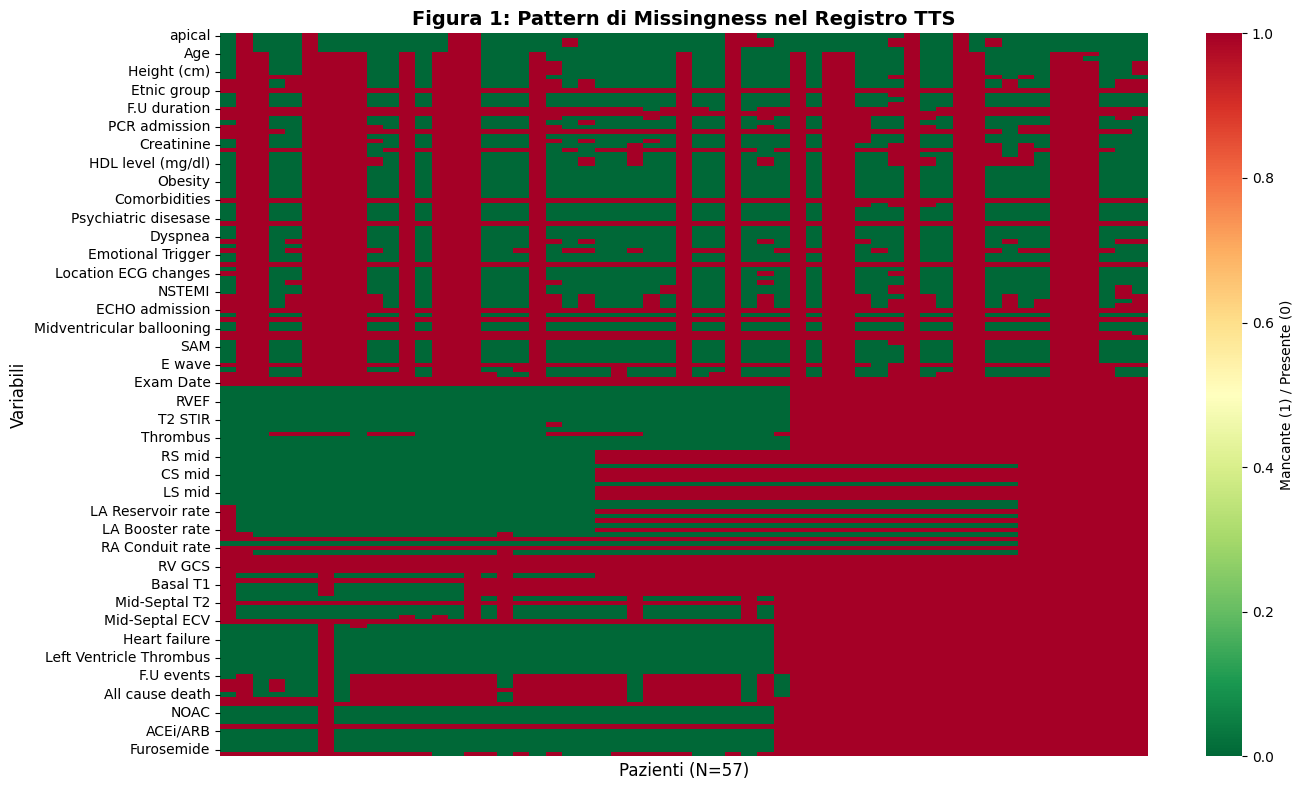

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELLA 7: FIGURA 1 — Heatmap di Missingness
# ═══════════════════════════════════════════════════════════════

cols_miss = [c for c in df.columns
             if c != TARGET and df[c].isna().mean() > 0.05]
miss_matrix = df[cols_miss].isna().astype(int)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(miss_matrix.T, cmap='RdYlGn_r',
            cbar_kws={'label': 'Mancante (1) / Presente (0)'},
            xticklabels=False, ax=ax)
ax.set_xlabel('Pazienti (N=57)', fontsize=12)
ax.set_ylabel('Variabili', fontsize=12)
ax.set_title('Figura 1: Pattern di Missingness nel Registro TTS',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_PATH}figura_01_missingness_heatmap.png',
            dpi=300, bbox_inches='tight')
print(f'Figura 1 salvata')
plt.show()

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELLA 8: LITTLE'S MCAR TEST — versione robusta
# ═══════════════════════════════════════════════════════════════

from scipy.stats import chi2

def littles_mcar_test(df, min_complete=0.70):
    """
    Test MCAR di Little — versione robusta con pseudo-inversa.
    Usa solo variabili con completezza >= min_complete per evitare
    instabilità numerica con la matrice di covarianza.
    """
    num_cols = df.select_dtypes(include='number').columns.tolist()
    eligible = [c for c in num_cols
                if df[c].isna().mean() <= (1 - min_complete)
                and df[c].isna().mean() > 0]
    print(f'Variabili incluse nel test (completezza >= {min_complete*100:.0f}%): {len(eligible)}')

    df_sub      = df[eligible].copy()
    grand_mean  = df_sub.mean()
    grand_cov   = df_sub.cov()
    patterns    = df_sub.isna().apply(lambda r: tuple(r), axis=1)
    d2, dof     = 0.0, 0

    for pat, grp in df_sub.groupby(patterns):
        obs = [eligible[i] for i, m in enumerate(pat) if not m]
        if len(obs) < 2: continue
        g = grp[obs].dropna()
        if len(g) < 2: continue
        try:
            inv  = np.linalg.pinv(grand_cov.loc[obs, obs].values)
            diff = g.mean().values - grand_mean[obs].values
            val  = float(len(g) * diff @ inv @ diff)
            if np.isfinite(val) and val >= 0:
                d2  += val
                dof += len(obs)
        except Exception:
            pass

    if d2 == 0 or dof == 0:
        print('Test non calcolabile: variabili insufficienti.')
        return None, None, None

    pval = float(1 - chi2.cdf(d2, dof))
    return d2, dof, pval


d2, dof, pval = littles_mcar_test(df, min_complete=0.70)

if d2 is not None:
    print(f'\nLittle MCAR Test: chi2={d2:.2f}, df={dof}, p={pval:.4f}')
    if pval < 0.05:
        print('→ MCAR RIGETTATO: i dati non mancano in modo casuale.')
        print('  Procedere con analisi MAR/MNAR (cella successiva).')
    else:
        print('→ MCAR non rigettato: dati compatibili con missingness casuale.')

Variabili incluse nel test (completezza >= 70%): 11

Little MCAR Test: chi2=15.95, df=22, p=0.8185
→ MCAR non rigettato: dati compatibili con missingness casuale.


In [22]:
# ═══════════════════════════════════════════════════════════════
# CELLA 9: ANALISI MAR vs MNAR
# Per variabili con > 30% di missing: AUC > 0.70 → MAR
# ═══════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

high_miss = [c for c in df.columns
             if c != TARGET and df[c].isna().mean() > 0.30]
results_mar = []

for var in high_miss:
    y     = df[var].isna().astype(int)
    preds = [c for c in df.select_dtypes('number').columns
             if c != var and c != TARGET
             and df[c].isna().mean() < 0.50]
    if len(preds) < 3 or y.sum() < 5:
        continue
    X_imp = SimpleImputer(strategy='median').fit_transform(df[preds])
    try:
        lr  = LogisticRegression(max_iter=1000, random_state=SEED)
        lr.fit(X_imp, y)
        auc = roc_auc_score(y, lr.predict_proba(X_imp)[:, 1])
        results_mar.append({
            'variabile':    var,
            'pct_missing':  round(df[var].isna().mean() * 100, 1),
            'AUC':          round(auc, 3),
            'meccanismo':   'MAR (probabile)' if auc > 0.70 else 'MCAR/MNAR'
        })
    except Exception:
        pass

tab2 = pd.DataFrame(results_mar).sort_values('pct_missing', ascending=False)
tab2.to_csv(f'{TAB_PATH}tabella_02_MAR_MNAR.csv', index=False)
print(f'Tabella 2 salvata ({len(tab2)} variabili analizzate)')
print(f'\nVariabili MAR (AUC > 0.70): {(tab2["AUC"] > 0.70).sum()}')
print(f'Variabili MCAR/MNAR:        {(tab2["AUC"] <= 0.70).sum()}')
print(tab2.to_string(index=False))

Tabella 2 salvata (124 variabili analizzate)

Variabili MAR (AUC > 0.70): 124
Variabili MCAR/MNAR:        0
                     variabile  pct_missing   AUC      meccanismo
              Basal ballooning         98.2 1.000 MAR (probabile)
                        E wave         98.2 1.000 MAR (probabile)
                       PCR max         94.7 1.000 MAR (probabile)
                  F.U duration         93.0 1.000 MAR (probabile)
                 Date Death_FU         93.0 1.000 MAR (probabile)
                 DATE MACCE FU         87.7 0.980 MAR (probabile)
                   Hematocrite         87.7 1.000 MAR (probabile)
                         MACCE         86.0 0.967 MAR (probabile)
                    Type_MACCE         86.0 0.967 MAR (probabile)
               All cause death         82.5 0.970 MAR (probabile)
                    F.U events         82.5 0.970 MAR (probabile)
                 Furosemide_mg         82.5 1.000 MAR (probabile)
                        Mid T1    

In [23]:
# ═══════════════════════════════════════════════════════════════
# CELLA 8: FREEZE AMBIENTE — eseguire a fine fase
# Salva le versioni esatte dei pacchetti per riproducibilità.
# ═══════════════════════════════════════════════════════════════

import subprocess
req_path = f'{BASE}/requirements_fase1.txt'
with open(req_path, 'w') as f:
    result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)
    f.write(result.stdout)
print(f'Environment salvato in: {req_path}')

Environment salvato in: /content/drive/MyDrive/TTS_Research/requirements_fase1.txt
